# Kyrgyzstan Employment and Wages Analysis (1998-2013)

## Objective
This notebook analyzes the socio-economic landscape of Kyrgyzstan by integrating two datasets: the number of employees and their average wages across various economic activities. 

### Scope of Work:
1. **Data Cleaning**: A unified modular function to clean both employment and wage datasets.
2. **Data Integration**: Merging employment counts with wage levels for deeper insights.
3. **Visualization**: Identifying correlations between workforce size and compensation levels.

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set aesthetic parameters for premium visualizations
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Unified Data Cleaning Function

We use a single function to process both CSV files. This function removes non-English text, handles metadata, and ensures numeric consistency (including handling commas in wage values).

In [72]:
def clean_kg_dataset(file_path):
    """
    Cleans Kyrgyzstan statistical datasets by skipping metadata,
    removing non-English columns, and standardizing numeric formats.
    """
    # Find the header row dynamically by searching for the 'Items' column
    header_row = 0
    with open(file_path, 'r', encoding='utf-8', errors='ignore') as f:
        for i, line in enumerate(f):
            if 'Items' in line:
                header_row = i
                break
    
    # Read CSV, skipping the identified metadata rows
    df = pd.read_csv(file_path, skiprows=header_row)
    
    # Drop Kyrgyz and Russian name columns (first two)
    df = df.drop(columns=df.columns[:2])
    
    # Standardize activity column
    df = df.rename(columns={'Items': 'Economic_Activity'})
    
    # Drop rows where Economic_Activity is null or all values are null
    df = df.dropna(subset=['Economic_Activity'], how='all')
    df = df.dropna(how='all', subset=df.columns[1:])
    
    df['Economic_Activity'] = df['Economic_Activity'].astype(str).str.strip()
    
    # Convert year columns to numeric
    years = df.columns[1:]
    for col in years:
        # Robust numeric conversion: convert to string, remove commas, then to numeric
        df[col] = df[col].astype(str).str.replace(',', '').str.strip()
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    return df

# Load and clean datasets
emp_path = 'data/Number of employees of enterprises and organizations by type of economic activity.csv'
wage_path = 'data/Wages by type of economic activity.csv'

df_emp = clean_kg_dataset(emp_path)
df_wage = clean_kg_dataset(wage_path)

print("Datasets loaded and cleaned successfully.")
print(f"Employment sectors: {len(df_emp['Economic_Activity'].unique())}")
print(f"Wage sectors: {len(df_wage['Economic_Activity'].unique())}")
display(df_emp.head(3))

Datasets loaded and cleaned successfully.
Employment sectors: 16
Wage sectors: 16


,Economic_Activity,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
1,Total,678280.0,649402.0,623186.0,594920.0,571301.0,560368.0,554566.0,550009.0,533277.0,559741.0,573858.0,563334.0,559368.1,571218.5,597525.9,581391.0
3,"Agriculture, hunting and forestry",86549.0,72693.0,59455.0,45918.0,40405.0,38475.0,35553.0,30473.0,27732.0,22061.0,20129.0,18578.0,17839.4,17026.3,15395.6,14392.4
4,Fishing and fishery,130.0,448.0,104.0,768.0,132.0,343.0,59.0,65.0,53.0,92.0,99.0,93.0,89.0,104.0,78.0,80.0


## 2. Data Integration

We will now merge the employment and wage data to create a comprehensive view of the labor market.

In [73]:
def melt_dataset(df, value_name):
    # Filter out 'Total' for sectoral analysis and remove any empty activities
    df_sectors = df[(df['Economic_Activity'] != 'Total') & (df['Economic_Activity'] != 'nan')].copy()
    melted = df_sectors.melt(id_vars='Economic_Activity', var_name='Year', value_name=value_name)
    melted['Year'] = melted['Year'].astype(int)
    return melted

# Melt both datasets
df_emp_melted = melt_dataset(df_emp, 'Employees')
df_wage_melted = melt_dataset(df_wage, 'Avg_Wage')

# Merge datasets on Activity and Year
df_integrated = pd.merge(df_emp_melted, df_wage_melted, on=['Economic_Activity', 'Year'])

print(f"Integrated dataset created with {len(df_integrated)} rows.")
if len(df_integrated) > 0:
    display(df_integrated.head())
else:
    print("Warning: The integrated dataset is empty. Check if sector names match exactly between files.")

Integrated dataset created with 240 rows.


,Economic_Activity,Year,Employees,Avg_Wage
0,"Agriculture, hunting and forestry",1998,86549.0,402
1,Fishing and fishery,1998,130.0,510
2,Mining industry,1998,8244.0,1415
3,Manufacturing industry,1998,105926.0,1406
4,Production and distribution of electricity gas...,1998,20260.0,1440


## 3. Advanced Insights: Employment vs. Wages

### Insight 1: Sectoral Disparity (2013)
Which sectors pay the best versus which ones employ the most people?

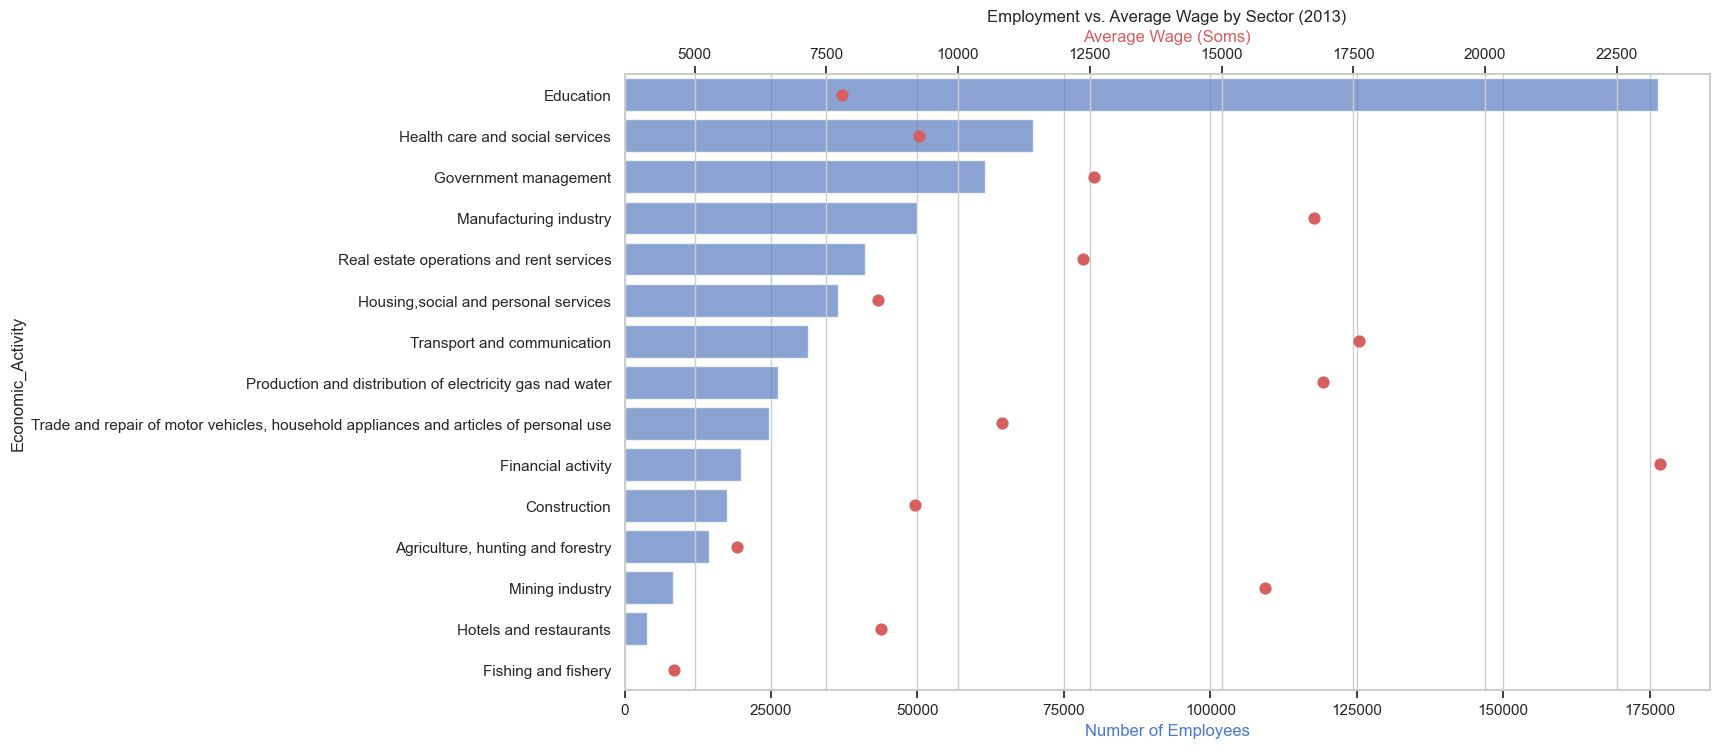

In [74]:
latest = df_integrated[df_integrated['Year'] == 2013].sort_values(by='Employees', ascending=False)

if not latest.empty:
    fig, ax1 = plt.subplots(figsize=(14, 8))

    # Bar chart for employees
    sns.barplot(data=latest, x='Employees', y='Economic_Activity', ax=ax1, alpha=0.7)
    ax1.set_xlabel('Number of Employees', color='b')
    ax1.set_title('Employment vs. Average Wage by Sector (2013)')

    # Twin axis for wages
    ax2 = ax1.twiny()
    sns.pointplot(data=latest, x='Avg_Wage', y='Economic_Activity', ax=ax2, color='r', linestyle='none')
    ax2.set_xlabel('Average Wage (Soms)', color='r')

    plt.show()
else:
    print("Warning: No integrated data available for the year 2013.")

### Insight 2: Employment Distribution (2013)
How is the workforce distributed across different sectors? This donut chart visualizes the dominant employers in the market.

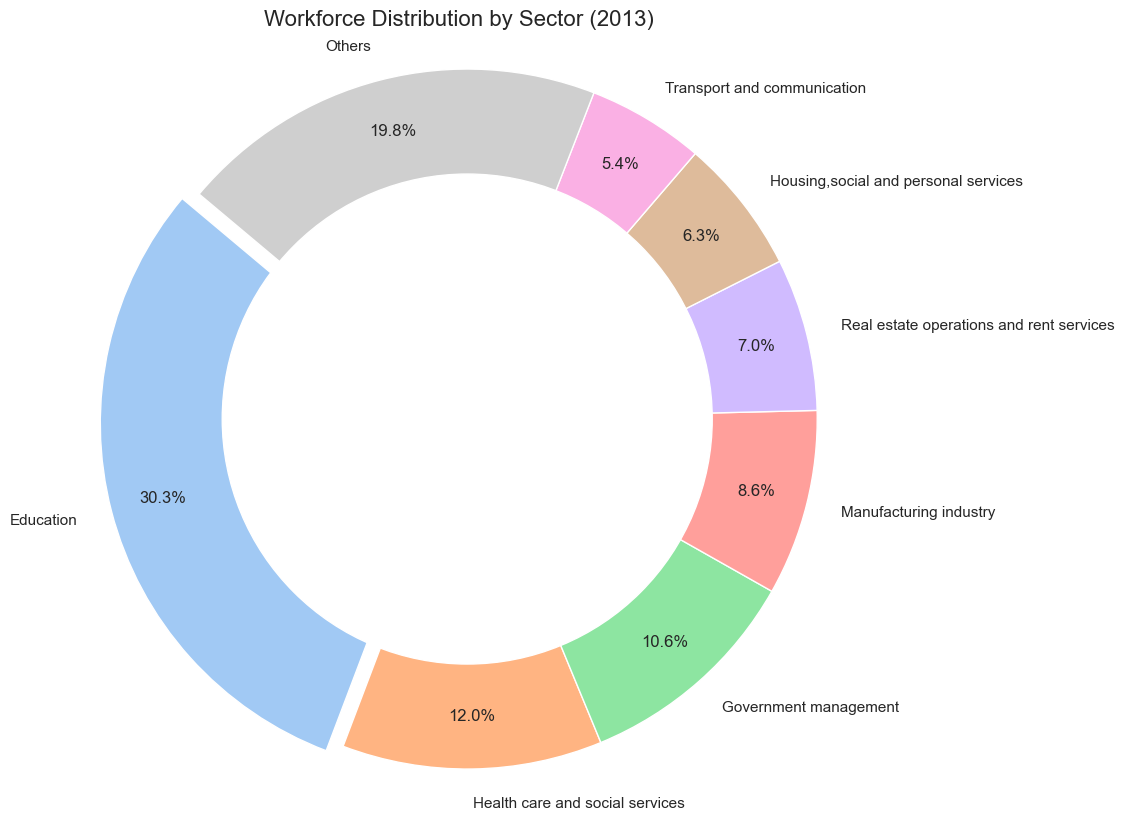

In [ ]:
if not latest.empty:
    # grouping smaller sectors into 'Others' for clarity
    top_n = min(7, len(latest))
    pie_data = latest.head(top_n).copy()
    
    if len(latest) > top_n:
        others_count = latest['Employees'].iloc[top_n:].sum()
        others_row = pd.DataFrame({
            'Economic_Activity': ['Others'],
            'Employees': [others_count]
        })
        pie_final = pd.concat([pie_data, others_row], ignore_index=True)
    else:
        pie_final = pie_data

    # Ensure we only plot non-NaN values
    pie_final = pie_final.dropna(subset=['Employees'])
    
    if not pie_final.empty and pie_final['Employees'].sum() > 0:
        plt.figure(figsize=(10, 10))
        n_slices = len(pie_final)
        colors = sns.color_palette('pastel')[0:n_slices]
        # Explode the largest slice
        explode = [0.05] + [0]*(n_slices - 1)
        
        plt.pie(pie_final['Employees'], labels=pie_final['Economic_Activity'], 
                autopct='%1.1f%%', startangle=140, colors=colors, pctdistance=0.85, 
                explode=explode)
        
        # Draw white circle at center for donut effect
        centre_circle = plt.Circle((0,0), 0.70, fc='white')
        plt.gca().add_artist(centre_circle)
        
        plt.title('Workforce Distribution by Sector (2013)', fontsize=16)
        plt.axis('equal')
        plt.show()
    else:
        print("Insufficient numeric data for employment distribution chart.")
else:
    print("No data available for the year 2013.")

### Insight 3: Wage Evolution Over Time (1998-2013)
Tracking the growth of average wages in key sectors helps identify which industries have seen the most significant economic progress.

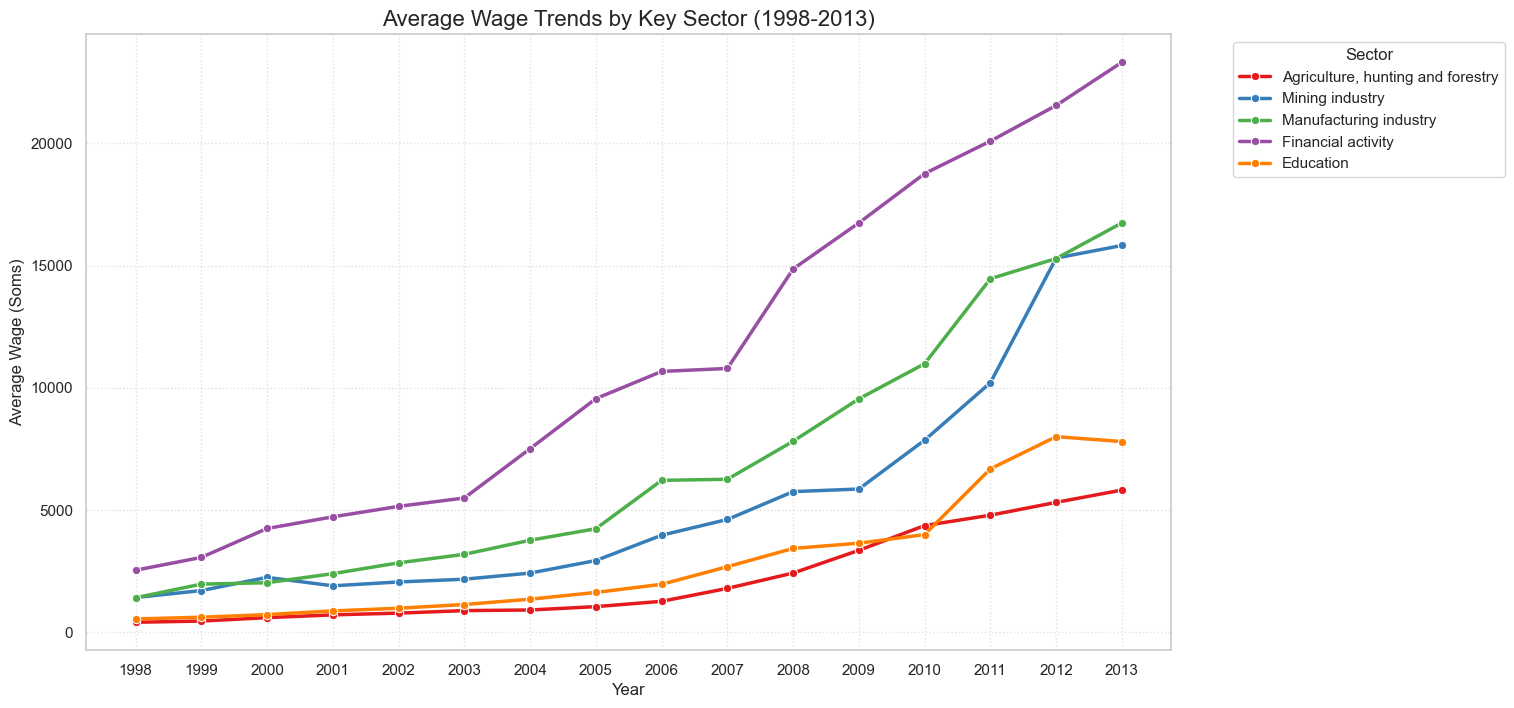

In [ ]:
plt.figure(figsize=(14, 8))

key_sectors = [
    'Education', 
    'Financial activity', 
    'Manufacturing industry', 
    'Agriculture, hunting and forestry',
    'Mining industry'
]

df_trends = df_integrated[df_integrated['Economic_Activity'].isin(key_sectors)]

if not df_trends.empty:
    sns.lineplot(data=df_trends, x='Year', y='Avg_Wage', hue='Economic_Activity', 
                 marker='o', linewidth=2.5, palette='Set1')
    
    plt.title('Average Wage Trends by Key Sector (1998-2013)', fontsize=16)
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Average Wage (Soms)', fontsize=12)
    plt.legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(df_integrated['Year'].unique())
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.show()
else:
    print("no data")

## 4. Conclusion

The integrated analysis highlights a significant economic trend in Kyrgyzstan:
1. **Dominant Sectors**: The **Education** sector remains a massive employer, though its wage growth has lagged behind industrial sectors.
2. **Financial Surge**: **Financial Activity** has seen the most dramatic increase in average wages, despite employing a relatively small portion of the workforce.
3. **Industrial Progress**: **Mining** and **Manufacturing** show steady growth in both compensation and employment stability.